# Gaussian Wavefront Sensing (funtion)
xchong@lbl.gov, 16th Jan 2023

based on `20240116_xc_wavefront_sensing_fun.ipynb` ([github](https://github.com/dream-beam/dream-test/blob/main/wavefront_sim/20240116_xc_wavefront_sensing_fun.ipynb))


we are going to do wavefront sensing for gaussian source: generate a gaussian souce, add grating, do propagation



# Part 1 Definitions of functions

# define parameters

In [42]:
import numpy as np
import matplotlib.pyplot as plt
Dx_m = 10e-3
dx_m = 0.1e-6
Nx = int(Dx_m/dx_m)
x_m = np.linspace(-0.5, 0.5, num = Nx) * Dx_m
E_eV = 8000
wavelength_m  = 1.2398e-6 / E_eV
pitch_m =  1e-5
plot_inter=False

# define gaussian function

In [43]:
#define gaussian function
def gaussian(x_px, mean_px, fwhm_px):
    '''
    GAUSSIAN Returns a 1D gaussian
    gaussian(x_px, mean_px, fwhm_px)
    :param x_px: numpy array
    :param mean_px: double
    :param fwhm_px: double
    :return: numpy array
    '''
    sigma_x = fwhm_px/(2*np.sqrt(2*np.log(2)))
    source_gaussian=np.exp(-((x_px-mean_px)/(np.sqrt(2)*sigma_x))**2)
    return source_gaussian

# define the propagation function

In [44]:
# define the propagation function
def ft(t):
    return np.fft.fftshift( np.fft.fft(np.fft.ifftshift(t)))

def ift(t):
    return np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(t)))

def fs(t):
    N = len(t)
    df_cpm = 1/(t[-1]-t[0])
    f_cpm = np.fft.fftshift(np.array([df_cpm*n if n<N/2 else df_cpm*(n-N) for n in range(N)]))
    return f_cpm

def propTF(E_in,L_m,lambda_m,z_m):
    #get input field array size
    Nx = len(E_in)
    dx = L_m/Nx; #sample interval

    #(dx<lambda.*z/L)

    fx = fs(np.arange(Nx)*dx);

    H=np.exp(-1j*np.pi*lambda_m*z_m*(fx**2))

    E_out = ft(ft(E_in)*H);

    return E_out

def propagation_with_grating(source_gaussian):
  grating_m = (np.sign(np.sin(2*np.pi*x_m/pitch_m))+1)/2
  z4_m = 2
  z7_m = 0.1

  #z_talbot_m=0.1
  z_talbot_m = pitch_m**2/wavelength_m


  num_plots=100
  a_array = np.linspace(0,z4_m,num=num_plots)
  b_array = np.linspace(0,z7_m,num=num_plots)
  E4_list=[]
  E7_list=[]

  # the first loop
  for a in a_array:
    E4 = propTF(source_gaussian, Dx_m, wavelength_m, a)
    E4 = E4/np.max(abs(E4))
    E4_list.append(E4)

  # add a lens with aberrations = 0.2
  E4 = propTF(source_gaussian, Dx_m, wavelength_m, z4_m)
  E4 = E4/np.max(abs(E4))
  E_g = E4*grating_m

  # the second loop
  for b in b_array:
    E7 = propTF(E_g, Dx_m, wavelength_m, b)
    E7 = E7/np.max(abs(E7))
    E7_list.append(E7)


  E_list = E4_list + E7_list

  return E_list


# define phase measurement function

In [ ]:
f_pm = fs(x_m)
#Antoine's code to get phase
def get_phase_AW(Ia):
  #select the last sample in E_list, then use fft

  Sa = ft(Ia)

  #create a mask
  f0_pm = 1/pitch_m
  mask= np.abs(f_pm- f0_pm)<0.6*f0_pm

  #select the signal around 10 mm by masking
  Sa_mask = Sa*mask

  Ia_mask = ift(Sa_mask)

  phi_a_rad = np.unwrap(np.angle(Ia_mask))

  return phi_a_rad


## Ken's code to get phase
def get_phase_Ken(a, wide=5., dc=5):

      # first, search for the first order peak
    f = np.fft.fft(a)
    fabs = np.abs(f)
    imax = len(fabs)//2 - 2  # look only at the left half because of the FFT. Integer division

    dc0 = np.short(dc)  # this is the minimum frequency where we can have a peak
    w = dc0 + np.squeeze(np.where(fabs[dc0:imax] == np.max(fabs[dc0:imax]))) # locate the 1st order peak

    x = np.arange(0,len(f))  # create a linear array to support the filtering
    filt = np.exp( -0.5 * ((x-w)/wide)**2 ) # filter the Fourier domain
    c = np.fft.ifft(filt * f)
    phi1 = np.arctan2(np.imag(c), np.real(c)) # extract the wrapped phase and the unwrap
    phi2 = np.unwrap(phi1)


    return phi2

  ###########################################
  # Get the amplitude from the data
  # we may have to zero-pad this and then remove padding in the end
def ExtractAmplitude(a, wide=7.):
    f1 = np.fft.fftshift(np.fft.fft(a))  # centered fft
    N = len(f1)
    wmiddle = N//2
    x = np.arange(0,N)
    filt = np.exp( -0.5 * ((x-wmiddle)/wide)**2 )  # Gaussian filter
    amp = np.abs(np.fft.ifft(np.fft.ifftshift(filt*f1)))
    return amp


# get the ground truth phase
def get_ground_truth(source_gaussian):
  p_m =12
  q_m = 12
  zf_m = 1/(1/p_m+1/q_m)
  # field at grating
  E4 = propTF(source_gaussian, Dx_m, wavelength_m, 12)
  Eg = propTF(E4, Dx_m, wavelength_m, 0)
  Es_truth = propTF(Eg, Dx_m, wavelength_m, 0.3)

  return Es_truth

# unwrapping from the center
def unwrapc(s):
  Nx = len(s)
  right = np.unwrap(s[int(Nx/2):])
  left  = np.flip(np.unwrap(s[(int(Nx/2)-1):-1:]))
  return np.concatenate((left,right))

# cumulative sum from the center
def cumsumc(s):
    Nx = len(s)
    right = np.cumsum(s[int(Nx/2):])
    left  = np.flip(np.cumsum(s[(int(Nx/2)-1):-1:]))
    return np.concatenate((left,right))

# Part 2 Start phase measurement

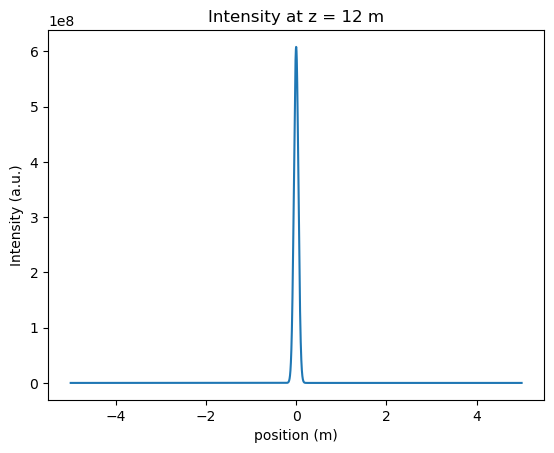

In [46]:
#generate the gaussian source and plot
size_fwhm_m=10*1e-6
source_gaussian = gaussian(x_m, 0, size_fwhm_m)

#do propagation
E0 = source_gaussian
p_m = 12
E_M = propTF(source_gaussian, Dx_m, wavelength_m, p_m)
plt.plot(x_m*1e3, np.abs(E_M)**2)
plt.xlabel('position (m)')
plt.ylabel('Intensity (a.u.)')
plt.title('Intensity at z = {} m'.format(p_m))
plt.show()

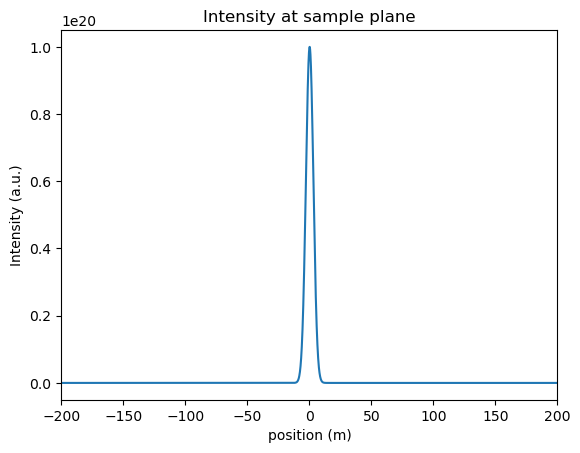

In [47]:
p_m = 12
q_m = 12

major_radius_m = 2400

# collimate
#major_radius_m = 2400*2

theta_rad = 5e-3
focal_length_m = major_radius_m*np.sin(theta_rad)/2

lens = np.exp(-1j*np.pi*x_m**2/(wavelength_m*focal_length_m))

E_toroid = E_M*(lens)
E_sample = propTF(E_toroid, Dx_m, wavelength_m, q_m)
plt.plot(x_m*1e6, np.abs(E_sample)**2)
plt.xlabel('position (m)')
plt.ylabel('Intensity (a.u.)')
plt.title('Intensity at sample plane')
plt.xlim((-200,200))
plt.show()

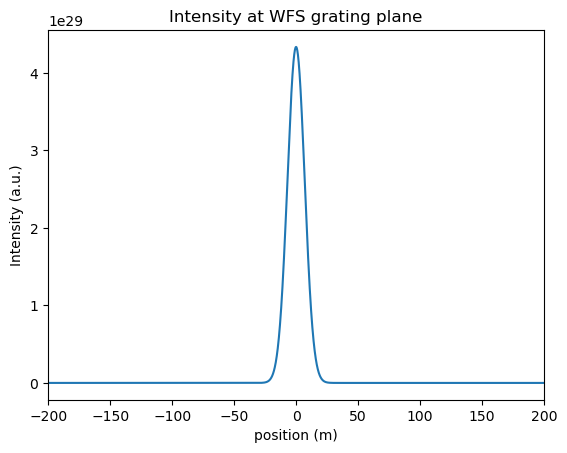

In [61]:
# The distance between the WFS YAG and the sample is 1300 mm
z_sample_grating_m = -1.6
z_grating_yag_m = 300e-3

E_WFS = propTF(E_sample, Dx_m, wavelength_m, z_sample_grating_m)
plt.plot(x_m*1e6, np.abs(E_WFS)**2)
plt.xlabel('position (m)')
plt.ylabel('Intensity (a.u.)')
plt.title('Intensity at WFS grating plane')
plt.xlim((-200,200))
plt.show()

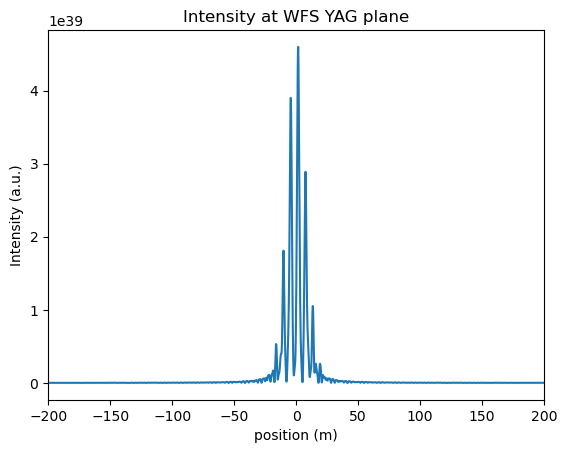

In [65]:
grating_pitch_m = 7e-6
grating = (np.sign(np.sin(2*np.pi*x_m/grating_pitch_m))+1)/2

E_YAG_gt = propTF(E_WFS, Dx_m, wavelength_m, z_grating_yag_m)
E_grating = E_WFS*grating
E_YAG = propTF(E_grating, Dx_m, wavelength_m, z_grating_yag_m)
plt.plot(x_m*1e6, np.abs(E_YAG)**2)
plt.xlabel('position (m)')
plt.ylabel('Intensity (a.u.)')
plt.title('Intensity at WFS YAG plane')
plt.xlim((-200,200))
plt.show()

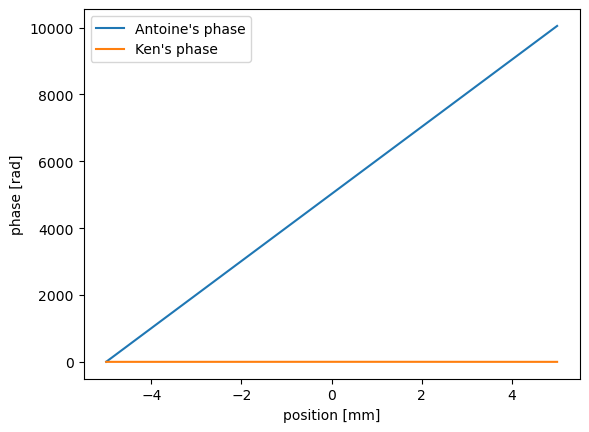

In [74]:
#Antoine's method: get phase
Ea = E_YAG
Ia = np.abs(Ea)**2
phi_a_rad = get_phase_AW(Ia)
phi_k_rad = get_phase_Ken(Ia)

plt.plot(x_m*1e3, phi_a_rad)
plt.plot(x_m*1e3, phi_k_rad)

plt.xlabel("position [mm]")
plt.ylabel("phase [rad]")
plt.legend(['Antoine\'s phase','Ken\'s phase'])
#plt.xlim((-0.2,0.2))
plt.show()

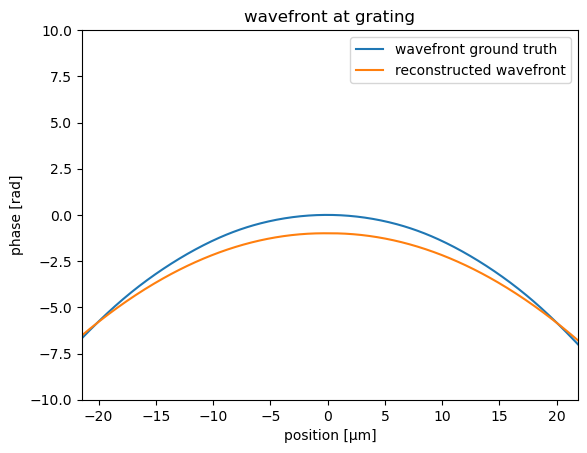

In [97]:
#reconstruct wavefront from phase
wavefront_rad = cumsumc(phi_k_rad-phi_k_rad[int(Nx/2)])*(dx_m)*(pitch_m)/wavelength_m/2
wavefront_rad = cumsumc(phi_a_rad-phi_a_rad[int(Nx/2)])*(dx_m)*(pitch_m)/wavelength_m/2

mask = abs(E_YAG_gt)**2/np.max(abs(E_YAG_gt)**2)>0.001

plt.plot(x_m*1e6, -wavefront_rad)
plt.plot(x_m*1e6, unwrapc(np.angle(E_YAG_gt)))
plt.xlabel("position [µm]")
plt.ylabel("phase [rad]")
plt.title('wavefront at grating')
plt.legend(['wavefront ground truth','reconstructed wavefront','unwrapped sheared field'])
plt.ylim((-10000,10000))
plt.ylim((-10,10))
plt.xlim(x_m[mask][0]*1e6, x_m[mask][-1]*1e6)
plt.show()

